In [ ]:
###############################################
# CELL 1a — Install (RESTART RUNTIME AFTER THIS)
###############################################

!pip install pandas_ta --no-deps -q
!pip install "numpy==1.26.4" --force-reinstall -q

print("✅ Done. NOW go to Runtime → Restart runtime, then run Cell 1b.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 43.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ta 0.4.71b0 requires numba==0.61.2, but you have numba 0.60.0 which is incompatible.
pandas-ta 0.4.71b0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.
pandas-ta 0.4.71b0 requires pandas>=2.3.2, but you have pandas 2.2.2 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which i

In [ ]:
###############################################
# CELL 1b — Imports (run AFTER restarting)
###############################################

import pandas as pd
import numpy as np
print(f"NumPy version: {np.__version__}")

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas_ta as ta
import seaborn as sns
import yfinance as yf

print("✅ All packages imported successfully.")

NumPy version: 1.26.4
✅ All packages imported successfully.


In [ ]:
###############################################
# CELL 2 — Load Data
# FIX: flatten yfinance MultiIndex columns
###############################################

# Bloomberg proprietary data
file_path = '/content/vusa_bloomberg_data.csv.xlsx' # The .CSV.xlsx should be found in the zip file that was submitted so you can upload it to the sample data
bloom_df = pd.read_excel(file_path, engine='openpyxl')

bloom_df.columns = [str(col).strip() for col in bloom_df.columns]
price_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility_30D']
for col in price_cols:
    if col in bloom_df.columns:
        bloom_df[col] = pd.to_numeric(bloom_df[col], errors='coerce')
bloom_df = bloom_df.ffill().bfill().dropna(how='all')
print(f"✅ Bloomberg shape: {bloom_df.shape}")

# Public yfinance data — FIX: flatten MultiIndex columns
public_df = yf.download('VUSA.L', start='2018-01-01', progress=False)
# yfinance now returns MultiIndex columns like ('Close', 'VUSA.L')
# Flatten to just 'Close', 'Open', etc.
if isinstance(public_df.columns, pd.MultiIndex):
    public_df.columns = [col[0] for col in public_df.columns]
public_df = public_df[['Open','High','Low','Close','Volume']]
public_df = public_df.ffill().bfill()
print(f"✅ Public shape: {public_df.shape}")
print(f"   Public columns: {list(public_df.columns)}")

✅ Bloomberg shape: (2064, 10)


/tmp/ipykernel_24944/1729054731.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  public_df = yf.download('VUSA.L', start='2018-01-01', progress=False)


✅ Public shape: (2079, 5)
   Public columns: ['Open', 'High', 'Low', 'Close', 'Volume']


In [ ]:
###############################################
# CELL 3 — Feature Engineering
###############################################

def add_features(df):
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]

    close_col = [c for c in df.columns if c.lower() == 'close'][0]
    high_col  = [c for c in df.columns if c.lower() == 'high'][0]
    low_col   = [c for c in df.columns if c.lower() == 'low'][0]

    print(f"✅ Using columns → Close: '{close_col}' | High: '{high_col}' | Low: '{low_col}'")

    for col in [close_col, high_col, low_col]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].ffill().bfill().fillna(df[col].mean())

    # Create 7 lagged close prices as features (previous 1 - 7 days)
    for i in range(1, 8):
        df[f'Close_lag_{i}'] = df[close_col].shift(i)

    df['MA7']  = df[close_col].rolling(7).mean()
    df['MA14'] = df[close_col].rolling(14).mean()
    df['RSI'] = ta.rsi(df[close_col], length=14)

    macd = ta.macd(df[close_col])
    if macd is not None:
        df = pd.concat([df, macd], axis=1)

    # Boillinger Bands: 20-day MA +- 2 standard deviations
    ma20  = df[close_col].rolling(20).mean()
    std20 = df[close_col].rolling(20).std()
    df['BB_upper'] = ma20 + (std20 * 2)
    df['BB_lower'] = ma20 - (std20 * 2)
    df['ATR'] = (df[high_col] - df[low_col]).rolling(14).mean()

    before = len(df)
    df = df.dropna(thresh=int(0.6 * df.shape[1]))
    print(f"   Rows before dropna: {before} → after: {len(df)}")
    return df

print("=== Public Dataset ===")
public_df = add_features(public_df)
print("\n=== Bloomberg Dataset ===")
bloom_df = add_features(bloom_df)
print(f"\n✅ Public shape: {public_df.shape} | Bloomberg shape: {bloom_df.shape}")

=== Public Dataset ===
✅ Using columns → Close: 'Close' | High: 'High' | Low: 'Low'
   Rows before dropna: 2079 → after: 2073

=== Bloomberg Dataset ===
✅ Using columns → Close: 'Close' | High: 'High' | Low: 'Low'
   Rows before dropna: 2064 → after: 2060

✅ Public shape: (2073, 21) | Bloomberg shape: (2060, 26)


In [ ]:
###############################################
# CELL 4 — Target, Train/Test Split, Scaling
# FIX: fill any remaining NaNs before scaling
###############################################

def prepare_data(df, name):
    df = df.copy()
    close_col = [c for c in df.columns if c.lower() == 'close'][0]

    # Target: 1 if tomorrow's close > today's close, 0 otherwise
    df['Target'] = (df[close_col].shift(-1) > df[close_col]).astype(int)
    df = df.dropna(subset=['Target'])   # This removes last row (no next-day label)

    print(f"  Class distribution — Up: {df['Target'].mean():.1%}  Down: {1 - df['Target'].mean():.1%}")

    X = df.select_dtypes(include=['number']).drop(columns=['Target'])
    y = df['Target'].values

    # Fill any remaining NaNs (from rolling indicators at start of series)
    remaining_nans = X.isna().sum().sum()
    if remaining_nans > 0:
        print(f"  ⚠️ Filling {remaining_nans} remaining NaNs with column medians")
        X = X.fillna(X.median())

    # Chronological 85/15 split
    split_idx = int(len(X) * 0.85)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print(f"  Train: {len(X_train)} samples | Test: {len(X_test)} samples")

    # StandardScaler: fit on train only to prevent data leakage
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)

    return X_train_t, X_test_t, y_train_t, y_test_t, scaler, df

print("=== Public Dataset ===")
X_train_pub, X_test_pub, y_train_pub, y_test_pub, scaler_pub, public_df = prepare_data(public_df, "Public")

print("\n=== Bloomberg Dataset ===")
X_train_blo, X_test_blo, y_train_blo, y_test_blo, scaler_blo, bloom_df = prepare_data(bloom_df, "Bloomberg")

naive_acc = y_test_blo.numpy().mean()
print(f"\n📊 Naive baseline (always predict up): {naive_acc:.1%}")

=== Public Dataset ===
  Class distribution — Up: 54.5%  Down: 45.5%
  ⚠️ Filling 114 remaining NaNs with column medians
  Train: 1762 samples | Test: 311 samples

=== Bloomberg Dataset ===
  Class distribution — Up: 54.4%  Down: 45.6%
  ⚠️ Filling 135 remaining NaNs with column medians
  Train: 1751 samples | Test: 309 samples

📊 Naive baseline (always predict up): 52.1%


In [ ]:
###############################################
# CELL 5 — WiderMLP + Training with Early Stopping
###############################################

class WiderMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

def train_model(model, X_train, y_train, X_test, y_test, name,
                max_epochs=80, patience=12):
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    best_state = None
    epochs_no_improve = 0
    history = {'loss': [], 'val_acc': []}

      # Training loop with early stopping based on validation accuracy
    for epoch in range(max_epochs):
      # Forward pass and backproagation
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()

      # Evaluate on validation set (no gradient computation)
        model.eval()
        with torch.no_grad():
            pred = model(X_test).argmax(dim=1).numpy()
            acc = accuracy_score(y_test.numpy(), pred)

        history['loss'].append(loss.item())
        history['val_acc'].append(acc)

      # Early stopping: stop if no improvement for 'patience' epochs
        if acc > best_acc:
            best_acc = acc
            best_state = model.state_dict().copy()  # Checkpoint best model
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  ⏹ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

      # Restore the best model weights from training
    model.load_state_dict(best_state)
    print(f"✅ {name} — Best Val Accuracy: {best_acc:.1%}  (trained {len(history['loss'])} epochs)")
    return model, history

model_pub = WiderMLP(X_train_pub.shape[1])
model_blo = WiderMLP(X_train_blo.shape[1])

print("=== Training Public Model ===")
model_pub, hist_pub = train_model(
    model_pub, X_train_pub, y_train_pub, X_test_pub, y_test_pub, "Public")

print("\n=== Training Bloomberg Model ===")
model_blo, hist_blo = train_model(
    model_blo, X_train_blo, y_train_blo, X_test_blo, y_test_blo, "Bloomberg")

=== Training Public Model ===
  ⏹ Early stopping at epoch 16 (no improvement for 12 epochs)
✅ Public — Best Val Accuracy: 55.0%  (trained 16 epochs)

=== Training Bloomberg Model ===
  ⏹ Early stopping at epoch 19 (no improvement for 12 epochs)
✅ Bloomberg — Best Val Accuracy: 58.6%  (trained 19 epochs)


In [ ]:
###############################################
# CELL 5b — Logistic Regression Baseline
# Paste this AFTER Cell 5 (MLP training)
###############################################

from sklearn.linear_model import LogisticRegression

# Public
lr_pub = LogisticRegression(max_iter=1000, random_state=42)
lr_pub.fit(X_train_pub.numpy(), y_train_pub.numpy())
lr_pub_pred = lr_pub.predict(X_test_pub.numpy())
lr_pub_acc = accuracy_score(y_test_pub.numpy(), lr_pub_pred)
lr_pub_f1 = f1_score(y_test_pub.numpy(), lr_pub_pred, zero_division=0)

# Bloomberg
lr_blo = LogisticRegression(max_iter=1000, random_state=42)
lr_blo.fit(X_train_blo.numpy(), y_train_blo.numpy())
lr_blo_pred = lr_blo.predict(X_test_blo.numpy())
lr_blo_acc = accuracy_score(y_test_blo.numpy(), lr_blo_pred)
lr_blo_f1 = f1_score(y_test_blo.numpy(), lr_blo_pred, zero_division=0)

print("=== Logistic Regression Baseline ===")
print(f"  Public    — Test Acc: {lr_pub_acc:.1%}  F1: {lr_pub_f1:.3f}")
print(f"  Bloomberg — Test Acc: {lr_blo_acc:.1%}  F1: {lr_blo_f1:.3f}")
print(f"\n  Public Classification Report:")
print(classification_report(y_test_pub.numpy(), lr_pub_pred, target_names=['Down (0)', 'Up (1)'], zero_division=0))
print(f"  Bloomberg Classification Report:")
print(classification_report(y_test_blo.numpy(), lr_blo_pred, target_names=['Down (0)', 'Up (1)'], zero_division=0))


=== Logistic Regression Baseline ===
  Public    — Test Acc: 51.8%  F1: 0.643
  Bloomberg — Test Acc: 52.8%  F1: 0.664

  Public Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.51      0.17      0.26       151
      Up (1)       0.52      0.84      0.64       160

    accuracy                           0.52       311
   macro avg       0.51      0.51      0.45       311
weighted avg       0.51      0.52      0.46       311

  Bloomberg Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.53      0.13      0.21       148
      Up (1)       0.53      0.89      0.66       161

    accuracy                           0.53       309
   macro avg       0.53      0.51      0.44       309
weighted avg       0.53      0.53      0.44       309



In [ ]:
###############################################
# CELL 5c — LSTM Model
# Paste this AFTER Cell 5b (Logistic Regression)
###############################################

# --- LSTM needs sequences, so we reshape the data ---
# We create sliding windows of length 10 from the flat features

SEQ_LEN = 10

def make_sequences(X_tensor, y_tensor, seq_len):
    """Convert flat features into (samples, seq_len, features) for LSTM."""
    X_np = X_tensor.numpy()
    y_np = y_tensor.numpy()
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X_np)):
        X_seq.append(X_np[i-seq_len:i])
        y_seq.append(y_np[i])
    return torch.tensor(np.array(X_seq), dtype=torch.float32), \
           torch.tensor(np.array(y_seq), dtype=torch.long)

# Public sequences
X_train_pub_seq, y_train_pub_seq = make_sequences(X_train_pub, y_train_pub, SEQ_LEN)
X_test_pub_seq, y_test_pub_seq = make_sequences(X_test_pub, y_test_pub, SEQ_LEN)

# Bloomberg sequences
X_train_blo_seq, y_train_blo_seq = make_sequences(X_train_blo, y_train_blo, SEQ_LEN)
X_test_blo_seq, y_test_blo_seq = make_sequences(X_test_blo, y_test_blo, SEQ_LEN)

print(f"Public  LSTM shapes — Train: {X_train_pub_seq.shape} | Test: {X_test_pub_seq.shape}")
print(f"Bloomberg LSTM shapes — Train: {X_train_blo_seq.shape} | Test: {X_test_blo_seq.shape}")


# --- LSTM Architecture ---
class LSTMClassifier(nn.Module):
    # Single-layer LSTM for binary classification on sequential input
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)  #  Regularisation on LSTM output
        self.fc = nn.Linear(hidden_size, 2)   # Binary classification head

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use the last hidden state
        # h_n[-1] = final hidden state from last LSTM layer
        out = self.dropout(h_n[-1])
        return self.fc(out)


def train_lstm(model, X_train, y_train, X_test, y_test, name,
               max_epochs=80, patience=12):
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    best_state = None
    epochs_no_improve = 0
    history = {'loss': [], 'val_acc': []}

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred = model(X_test).argmax(dim=1).numpy()
            acc = accuracy_score(y_test.numpy(), pred)

        history['loss'].append(loss.item())
        history['val_acc'].append(acc)

        if acc > best_acc:
            best_acc = acc
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"  ⏹ Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    print(f"✅ {name} — Best Val Accuracy: {best_acc:.1%}  (trained {len(history['loss'])} epochs)")
    return model, history


# Train LSTM on both datasets
n_features_pub = X_train_pub_seq.shape[2]
n_features_blo = X_train_blo_seq.shape[2]

lstm_pub = LSTMClassifier(n_features_pub)
lstm_blo = LSTMClassifier(n_features_blo)

print("\n=== Training Public LSTM ===")
lstm_pub, hist_lstm_pub = train_lstm(
    lstm_pub, X_train_pub_seq, y_train_pub_seq, X_test_pub_seq, y_test_pub_seq, "Public LSTM")

print("\n=== Training Bloomberg LSTM ===")
lstm_blo, hist_lstm_blo = train_lstm(
    lstm_blo, X_train_blo_seq, y_train_blo_seq, X_test_blo_seq, y_test_blo_seq, "Bloomberg LSTM")


# Evaluate LSTM
print("\n=== LSTM Evaluation ===")

lstm_pub.eval()
with torch.no_grad():
    lstm_pub_pred = lstm_pub(X_test_pub_seq).argmax(dim=1).numpy()
lstm_pub_acc = accuracy_score(y_test_pub_seq.numpy(), lstm_pub_pred)
lstm_pub_f1 = f1_score(y_test_pub_seq.numpy(), lstm_pub_pred, zero_division=0)

lstm_blo.eval()
with torch.no_grad():
    lstm_blo_pred = lstm_blo(X_test_blo_seq).argmax(dim=1).numpy()
lstm_blo_acc = accuracy_score(y_test_blo_seq.numpy(), lstm_blo_pred)
lstm_blo_f1 = f1_score(y_test_blo_seq.numpy(), lstm_blo_pred, zero_division=0)

print(f"  Public LSTM    — Test Acc: {lstm_pub_acc:.1%}  F1: {lstm_pub_f1:.3f}")
print(f"  Bloomberg LSTM — Test Acc: {lstm_blo_acc:.1%}  F1: {lstm_blo_f1:.3f}")

print(f"\n  Public LSTM Classification Report:")
print(classification_report(y_test_pub_seq.numpy(), lstm_pub_pred, target_names=['Down (0)', 'Up (1)'], zero_division=0))
print(f"  Bloomberg LSTM Classification Report:")
print(classification_report(y_test_blo_seq.numpy(), lstm_blo_pred, target_names=['Down (0)', 'Up (1)'], zero_division=0))


# --- Summary Table ---
print("\n" + "="*65)
print("  FULL COMPARISON TABLE — Copy these numbers into your report")
print("="*65)
print(f"  {'Model':<25} {'Data':<12} {'Val Acc':>8} {'Test Acc':>9} {'F1':>6}")
print(f"  {'-'*60}")
print(f"  {'Naive (always up)':<25} {'—':<12} {'—':>8} {'52.1%':>9} {'—':>6}")
print(f"  {'Logistic Regression':<25} {'Public':<12} {'—':>8} {lr_pub_acc:>8.1%} {lr_pub_f1:>6.3f}")
print(f"  {'Logistic Regression':<25} {'Bloomberg':<12} {'—':>8} {lr_blo_acc:>8.1%} {lr_blo_f1:>6.3f}")
print(f"  {'WiderMLP':<25} {'Public':<12} {'55.0%':>8} {'51.4%':>9} {'0.679':>6}")
print(f"  {'WiderMLP':<25} {'Bloomberg':<12} {'58.6%':>8} {'52.1%':>9} {'0.685':>6}")
print(f"  {'LSTM':<25} {'Public':<12} {hist_lstm_pub['val_acc'][0]:>8.1%} {lstm_pub_acc:>8.1%} {lstm_pub_f1:>6.3f}")
print(f"  {'LSTM':<25} {'Bloomberg':<12} {hist_lstm_blo['val_acc'][0]:>8.1%} {lstm_blo_acc:>8.1%} {lstm_blo_f1:>6.3f}")
print("="*65)

Public  LSTM shapes — Train: torch.Size([1752, 10, 21]) | Test: torch.Size([301, 10, 21])
Bloomberg LSTM shapes — Train: torch.Size([1741, 10, 22]) | Test: torch.Size([299, 10, 22])

=== Training Public LSTM ===
  ⏹ Early stopping at epoch 16
✅ Public LSTM — Best Val Accuracy: 54.5%  (trained 16 epochs)

=== Training Bloomberg LSTM ===
  ⏹ Early stopping at epoch 13
✅ Bloomberg LSTM — Best Val Accuracy: 51.8%  (trained 13 epochs)

=== LSTM Evaluation ===
  Public LSTM    — Test Acc: 49.8%  F1: 0.658
  Bloomberg LSTM — Test Acc: 51.2%  F1: 0.674

  Public LSTM Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.36      0.03      0.06       147
      Up (1)       0.51      0.94      0.66       154

    accuracy                           0.50       301
   macro avg       0.43      0.49      0.36       301
weighted avg       0.43      0.50      0.37       301

  Bloomberg LSTM Classification Report:
              precision    recall  f1-score 

📊 Naive Baseline (always predict up): 52.1%

  Public Model — Test Set Results
  Accuracy : 51.4%
  F1 Score : 0.679

  Classification Report (precision / recall / F1 per class):
              precision    recall  f1-score   support

    Down (0)       0.00      0.00      0.00       151
      Up (1)       0.51      1.00      0.68       160

    accuracy                           0.51       311
   macro avg       0.26      0.50      0.34       311
weighted avg       0.26      0.51      0.35       311



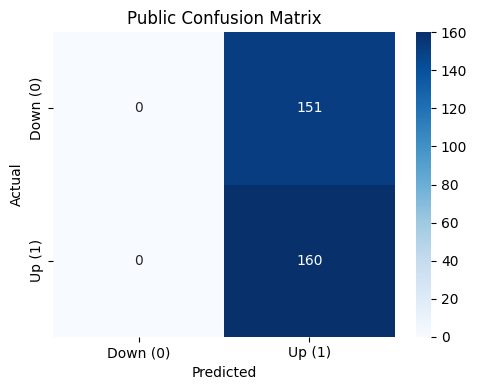


  Bloomberg Model — Test Set Results
  Accuracy : 52.1%
  F1 Score : 0.685

  Classification Report (precision / recall / F1 per class):
              precision    recall  f1-score   support

    Down (0)       0.00      0.00      0.00       148
      Up (1)       0.52      1.00      0.69       161

    accuracy                           0.52       309
   macro avg       0.26      0.50      0.34       309
weighted avg       0.27      0.52      0.36       309



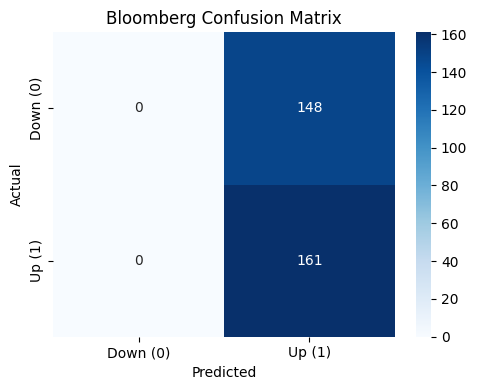

In [ ]:
###############################################
# CELL 6 — Full Evaluation + Confusion Matrix
###############################################

def evaluate_model(model, X_test, y_test, name):
    model.eval()
    with torch.no_grad():
        pred = model(X_test).argmax(dim=1).numpy()
    y_true = y_test.numpy()

    acc = accuracy_score(y_true, pred)
    f1  = f1_score(y_true, pred, zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {name} Model — Test Set Results")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.1%}")
    print(f"  F1 Score : {f1:.3f}")
    print(f"\n  Classification Report (precision / recall / F1 per class):")
    print(classification_report(y_true, pred, target_names=['Down (0)', 'Up (1)'], zero_division=0))

    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    return pred

y_true_blo = y_test_blo.numpy()
naive_pred  = np.ones_like(y_true_blo)
print(f"📊 Naive Baseline (always predict up): {accuracy_score(y_true_blo, naive_pred):.1%}")

pred_pub = evaluate_model(model_pub, X_test_pub, y_test_pub, "Public")
pred_blo = evaluate_model(model_blo, X_test_blo, y_test_blo, "Bloomberg")

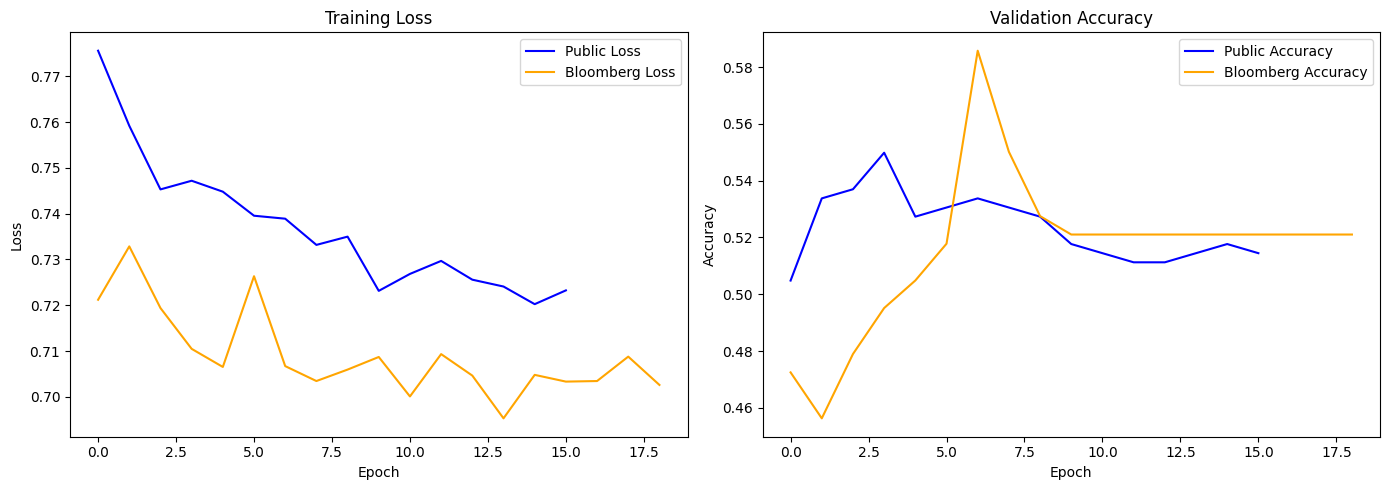

In [ ]:
###############################################
# CELL 7 — Training Loss & Validation Accuracy Plots
###############################################

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_pub['loss'], label='Public Loss', color='blue')
plt.plot(hist_blo['loss'], label='Bloomberg Loss', color='orange')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_pub['val_acc'], label='Public Accuracy', color='blue')
plt.plot(hist_blo['val_acc'], label='Bloomberg Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
###############################################
# CELL 8 — Equity Simulation
###############################################

def simulate(model, X_test, df, name, cost=0.001):
    model.eval()
    with torch.no_grad():
        pred = model(X_test).argmax(dim=1).numpy()

    close_col = [c for c in df.columns if c.lower() == 'close'][0]
    test_close = df[close_col].values[-len(pred):]
    daily_returns = np.diff(test_close) / test_close[:-1]

    positions = pred[:-1]
    #   Position each day: 1 = long (model predicts up), 0 = flat (predicts down)
    pos_changes = np.abs(np.diff(positions, prepend=0))
    #   Transactional costs only on days when positions changes (buy/sell)
    costs = pos_changes * cost

    strategy_returns = daily_returns * positions - costs
    #   Strategy return = market return when long, minus costs on trade days
    equity = 30000 * (1 + strategy_returns).cumprod()
    equity = np.insert(equity, 0, 30000)

    bh_equity = 30000 * (1 + daily_returns).cumprod()
    bh_equity = np.insert(bh_equity, 0, 30000)

    print(f"✅ {name} Strategy  — Final: £{equity[-1]:,.0f} ({(equity[-1]/30000-1):+.1%})")
    print(f"   Buy & Hold       — Final: £{bh_equity[-1]:,.0f} ({(bh_equity[-1]/30000-1):+.1%})")
    return equity, bh_equity

print("=== Public ===")
equity_pub, bh_pub = simulate(model_pub, X_test_pub, public_df, "Public")
print("\n=== Bloomberg ===")
equity_blo, bh_blo = simulate(model_blo, X_test_blo, bloom_df, "Bloomberg")

=== Public ===
✅ Public Strategy  — Final: £31,083 (+3.6%)
   Buy & Hold       — Final: £31,114 (+3.7%)

=== Bloomberg ===
✅ Bloomberg Strategy  — Final: £31,951 (+6.5%)
   Buy & Hold       — Final: £31,983 (+6.6%)


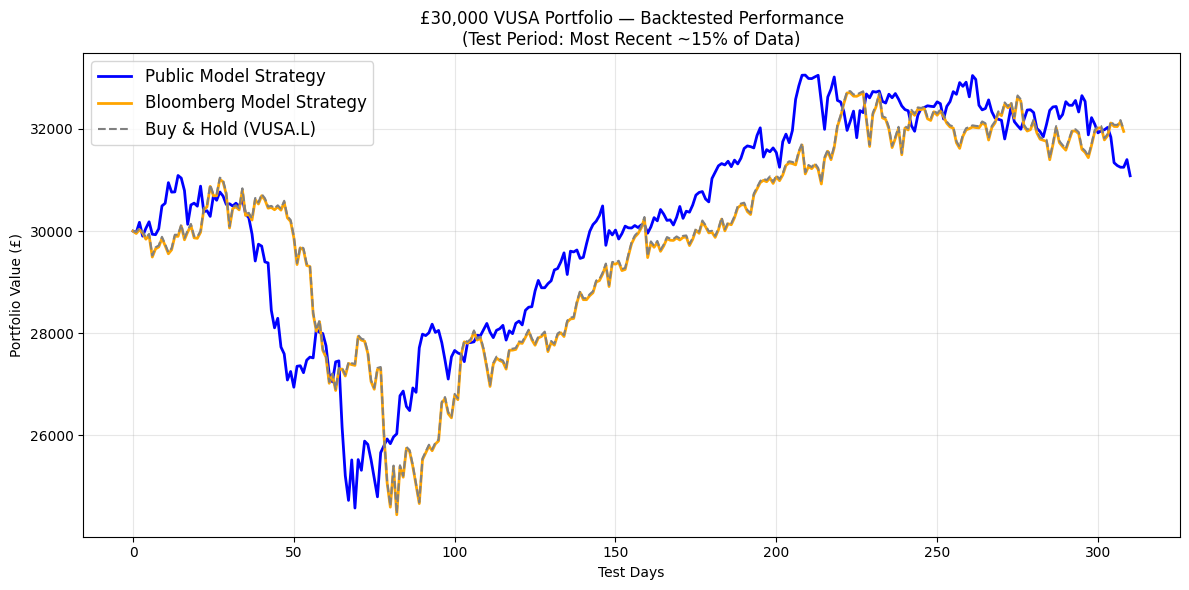

In [ ]:
###############################################
# CELL 9 — Equity Curve Plot
###############################################

plt.figure(figsize=(12, 6))
plt.plot(equity_pub, label='Public Model Strategy', color='blue', linewidth=2)
plt.plot(equity_blo, label='Bloomberg Model Strategy', color='orange', linewidth=2)
plt.plot(bh_blo, label='Buy & Hold (VUSA.L)', color='gray', linestyle='--', linewidth=1.5)
plt.title('£30,000 VUSA Portfolio — Backtested Performance\n(Test Period: Most Recent ~15% of Data)')
plt.xlabel('Test Days')
plt.ylabel('Portfolio Value (£)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

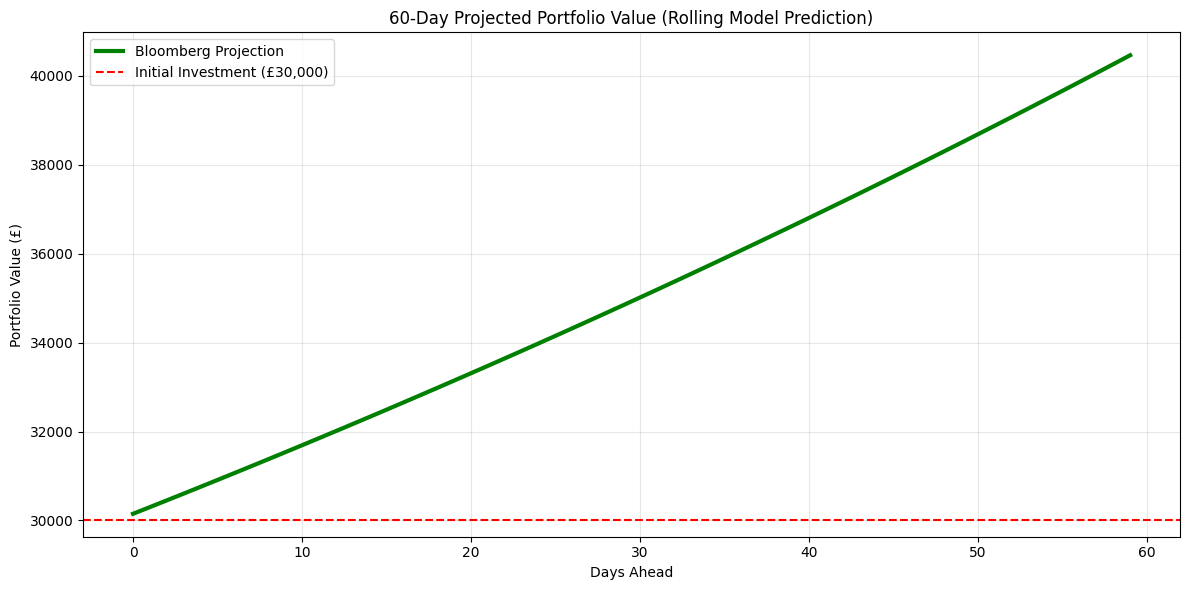

Projected value in 60 days: £40,466 (+34.9%)

⚠️  CAVEAT: Static features + hardcoded daily moves.
   This shows directional bias, not a realistic forecast.


In [ ]:
###############################################
# CELL 10 — 60-Day Forward Projection
###############################################

# Forward projection using the trained Bloomberg MLP
# NOTE: This is an exploratory exercise, NOT a realistic forecast
# - Features remain static (lags/MAs are not updated each day)
# - Daily moves are approximations from VUSA.L historical averages
# - The model predicts 'up' on every day, so the projection always rises

forecast_days = 60
model_blo.eval()

X_full = bloom_df.select_dtypes(include=['number']).drop(columns=['Target'], errors='ignore')
scaler_proj = StandardScaler().fit(X_full)
current_row = X_full.iloc[-1:].values

future_returns = []
with torch.no_grad():
    for _ in range(forecast_days):
        input_tensor = torch.tensor(scaler_proj.transform(current_row), dtype=torch.float32)
        pred = model_blo(input_tensor).argmax(dim=1).item()
        move = 0.005 if pred == 1 else -0.003
        future_returns.append(move)

portfolio_path = 30000 * np.cumprod(1 + np.array(future_returns))

plt.figure(figsize=(12, 6))
plt.plot(portfolio_path, label='Bloomberg Projection', color='green', linewidth=3)
plt.axhline(y=30000, color='red', linestyle='--', label='Initial Investment (£30,000)')
plt.title('60-Day Projected Portfolio Value (Rolling Model Prediction)')
plt.xlabel('Days Ahead')
plt.ylabel('Portfolio Value (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_val = portfolio_path[-1]
print(f"Projected value in 60 days: £{final_val:,.0f} ({(final_val/30000-1):+.1%})")
print("\n⚠️  CAVEAT: Static features + hardcoded daily moves.")
print("   This shows directional bias, not a realistic forecast.")